In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig4_reward_overrep_sparse')
figdir.mkdir(exist_ok=True, parents=True)

{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
SparseKO_02
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'exp_day': 6}
SparseKO_06
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 6, 'novel_arm': -1, 'exp_day': 6}
SparseKO_08
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': 1, 'exp_day': 6}
SparseKO_10
{'date': '03_06_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 10, 'novel_arm': -1, 'exp_day': 6}
SparseKO_11
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
SparseKO_13
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}
SparseKO_09


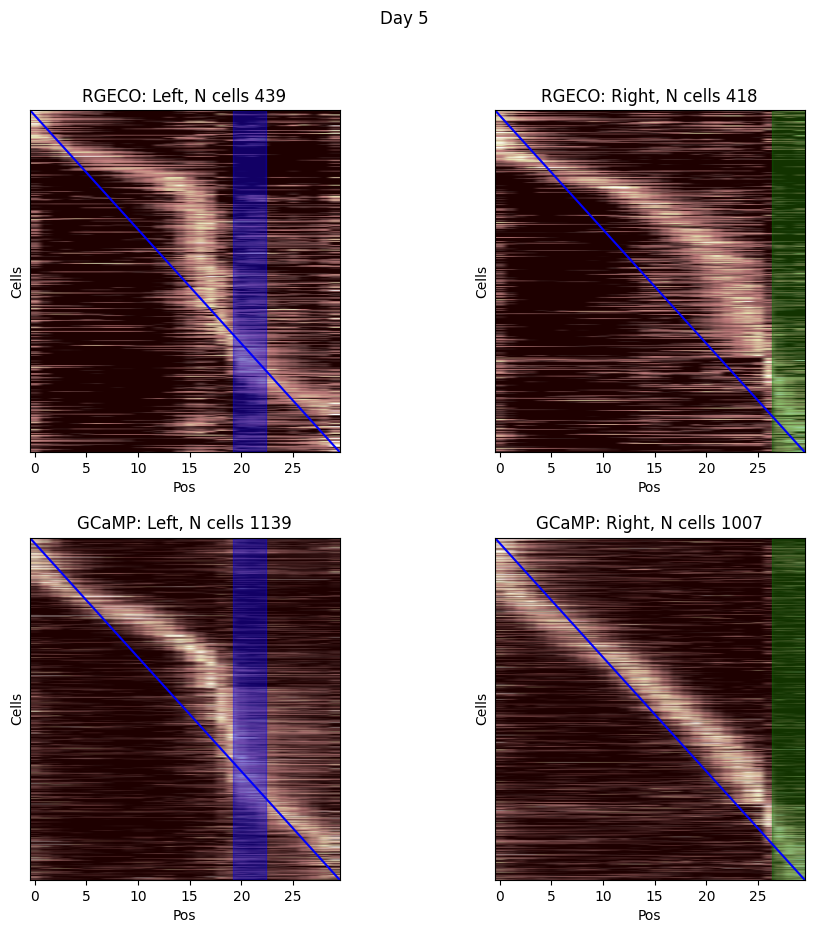

In [61]:
fig,ax = stx.reward_overrep.plot_leftright_crossval_placecells_withinday_sparse(5, ts_key = 'F_dff', all_cells=False)
# fig.savefig(figdir / "population_day5.pdf")
            

In [62]:
frac_cls = stx.reward_overrep.PeriRewardCellFrac_Sparse(sparse_mice, 
                                                        np.arange(6), 
                                                        place_cell_only=False,
                                                        ts_key='F_dff')

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': 1, 'exp_day': 3}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1,

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/reward_overrep.py:173: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_{ts_key}'][trial_mask,:,:],axis=0)


{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 14, 'novel_arm': -1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5}
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}


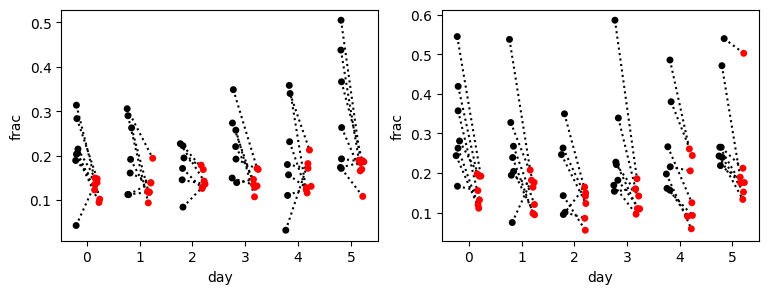

In [63]:
df = frac_cls.df

fig,ax = plt.subplots(1,2, figsize=[9,3])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='frac',
                hue='chan', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


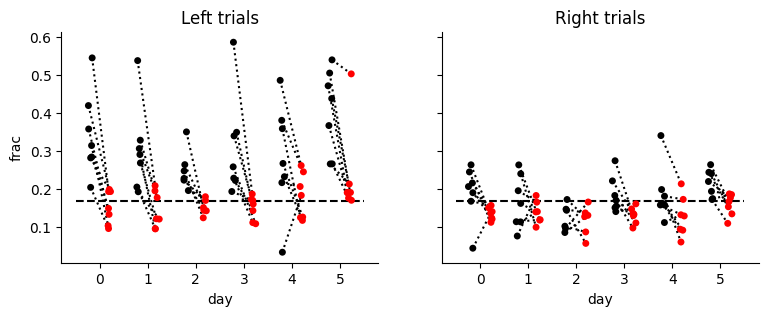

In [69]:
df = frac_cls.df

fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, lr in enumerate((-1,1)):
    ax[i] = sns.stripplot(data=df.loc[df['lr']==lr,:],
                x='day',
                y='frac',
                hue='chan', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Left trials')
ax[1].set_title('Right trials')
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.hlines(5./30, -.5,5.5, linestyle='--', color='black')


In [68]:
# left trials
df = frac_cls.df.copy()
df = df[df['lr'] == 1]
df['rank_frac'] = df['frac'].rank()


df['mouse'] = df['mouse'].astype('category')
# df = df.dropna()

mdl = smf.mixedlm('rank_frac ~ C(chan) * C(day)', df, groups = df["mouse"])
res = mdl.fit()
res.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelih

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM        Dependent Variable:        rank_frac
No. Observations:         82             Method:                    REML     
No. Groups:               7              Scale:                     391.4803 
Min. group size:          10             Log-Likelihood:            -320.7923
Max. group size:          12             Converged:                 No       
Mean group size:          11.7                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         29.714    7.604  3.908 0.000  14.811 44.617
C(chan)[T.channel_1]              29.571   10.576  2.796 0.005   8.843 50.300
C(day)[T.1]                        3.071   10.576  0.290 0.771 -17.657 23.800
C(day)[T.2]                       -5.782   11.051 -0.523 0.601 -27.441 15.877
C(day)[T.3]                       -2.143   10.576 -0.203 0.839 -22.871 18.586
C(day)[T.4]                       -1.714   10.576 -0.162 0.871 -22.443 19.014
C(day)[T.5]                       16.286   10.576  1.540 0.124  -4.443 37.014
C(chan)[T.channel_1]:C(day)[T.1] -18.643   14.957 -1.246 0.213 -47.957 10.672
C(chan)[T.channel_1]:C(day)[T.2] -26.905   15.567 -1.728 0.084 -57.416  3.607
C(chan)[T.channel_1]:C(day)[T.3]  -1.500   14.957 -0.100 0.920 -30.815 27.815
C(chan)[T.channel_1]:C(day)[T.4]  -5.429   14.957 -0.363 0.717 -34.743 23.886
C(chan)[T.channel_1]:C(day)[T.5]  -6.571   14.957 -0.439 0.660 -35.886 22.743
Group Var                         13.245    1.262                            
=============================================================================

"""

In [67]:
# right trials
df = frac_cls.df.copy()
df = df[df['lr'] == 1]
df['rank_frac'] = df['frac'].rank()


df['mouse'] = df['mouse'].astype('category')
# df = df.dropna()

mdl = smf.mixedlm('rank_frac ~ C(chan) * C(day)', df, groups = df["mouse"])
res = mdl.fit()
res.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelih

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM        Dependent Variable:        rank_frac
No. Observations:         82             Method:                    REML     
No. Groups:               7              Scale:                     391.4803 
Min. group size:          10             Log-Likelihood:            -320.7923
Max. group size:          12             Converged:                 No       
Mean group size:          11.7                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         29.714    7.604  3.908 0.000  14.811 44.617
C(chan)[T.channel_1]              29.571   10.576  2.796 0.005   8.843 50.300
C(day)[T.1]                        3.071   10.576  0.290 0.771 -17.657 23.800
C(day)[T.2]                       -5.782   11.051 -0.523 0.601 -27.441 15.877
C(day)[T.3]                       -2.143   10.576 -0.203 0.839 -22.871 18.586
C(day)[T.4]                       -1.714   10.576 -0.162 0.871 -22.443 19.014
C(day)[T.5]                       16.286   10.576  1.540 0.124  -4.443 37.014
C(chan)[T.channel_1]:C(day)[T.1] -18.643   14.957 -1.246 0.213 -47.957 10.672
C(chan)[T.channel_1]:C(day)[T.2] -26.905   15.567 -1.728 0.084 -57.416  3.607
C(chan)[T.channel_1]:C(day)[T.3]  -1.500   14.957 -0.100 0.920 -30.815 27.815
C(chan)[T.channel_1]:C(day)[T.4]  -5.429   14.957 -0.363 0.717 -34.743 23.886
C(chan)[T.channel_1]:C(day)[T.5]  -6.571   14.957 -0.439 0.660 -35.886 22.743
Group Var                         13.245    1.262                            
=============================================================================

"""

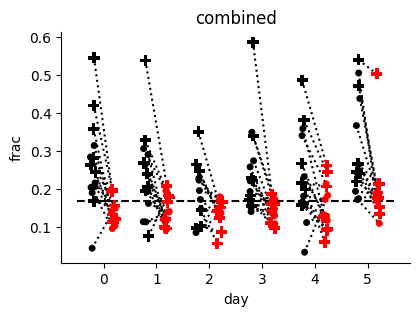

In [64]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
df_mu = frac_cls.df.groupby(['mouse','day','chan','ttype'])['frac'].mean().reset_index()
sns.stripplot(data=df_mu.loc[df_mu['ttype']=='fam',:],
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax, s= 5,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['ttype']=='nov',:],
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            marker='P',
            s=8,
            alpha=1.,
            dodge=True,
            ax=ax,
            legend=False)

for d in range(0,24,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.set_title('combined')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.hlines(5./30, -.5,5.5, linestyle='--', color='black')

# fig.savefig( figdir / 'frac_per_day_combined.pdf', bbox_inches='tight')

In [45]:
df = frac_cls.df.copy()
df['rank_frac'] = df['frac'].rank()


df['mouse'] = df['mouse'].astype('category')
# df = df.dropna()

mdl = smf.mixedlm('rank_frac ~ C(chan) * C(day) * C(ttype)', df, groups = df["mouse"])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                          MixedLM              Dependent Variable:              rank_frac
No. Observations:               164                  Method:                          REML     
No. Groups:                     7                    Scale:                           2258.8085
Min. group size:                20                   Log-Likelihood:                  -765.0175
Max. group size:                24                   Converged:                       Yes      
Mean group size:                23.4                                                           
-----------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------------
Intercept                                         72.143   18.530  3.893 0.000   35.824 108.462
C(chan)[T.channel_1]                              -7.786   25.404 -0.306 0.759  -57.577  42.006
C(day)[T.1]                                        4.857   25.404  0.191 0.848  -44.934  54.648
C(day)[T.2]                                       18.726   26.480  0.707 0.479  -33.175  70.627
C(day)[T.3]                                       13.143   25.404  0.517 0.605  -36.648  62.934
C(day)[T.4]                                       18.214   25.404  0.717 0.473  -31.577  68.006
C(day)[T.5]                                       30.714   25.404  1.209 0.227  -19.077  80.506
C(ttype)[T.nov]                                   17.000   25.404  0.669 0.503  -32.791  66.791
C(chan)[T.channel_1]:C(day)[T.1]                   3.214   35.927  0.089 0.929  -67.201  73.630
C(chan)[T.channel_1]:C(day)[T.2]                 -18.464   37.394 -0.494 0.621  -91.755  54.827
C(chan)[T.channel_1]:C(day)[T.3]                  15.071   35.927  0.420 0.675  -55.344  85.487
C(chan)[T.channel_1]:C(day)[T.4]                 -10.929   35.927 -0.304 0.761  -81.344  59.487
C(chan)[T.channel_1]:C(day)[T.5]                   3.571   35.927  0.099 0.921  -66.844  73.987
C(chan)[T.channel_1]:C(ttype)[T.nov]              28.143   35.927  0.783 0.433  -42.273  98.558
C(day)[T.1]:C(ttype)[T.nov]                      -31.714   35.927 -0.883 0.377 -102.130  38.701
C(day)[T.2]:C(ttype)[T.nov]                      -48.583   37.394 -1.299 0.194 -121.874  24.708
C(day)[T.3]:C(ttype)[T.nov]                      -29.357   35.927 -0.817 0.414  -99.773  41.058
C(day)[T.4]:C(ttype)[T.nov]                      -26.500   35.927 -0.738 0.461  -96.916  43.916
C(day)[T.5]:C(ttype)[T.nov]                      -20.214   35.927 -0.563 0.574  -90.630  50.201
C(chan)[T.channel_1]:C(day)[T.1]:C(ttype)[T.nov]  16.429   50.808  0.323 0.746  -83.154 116.011
C(chan)[T.channel_1]:C(day)[T.2]:C(ttype)[T.nov]  23.607   52.883  0.446 0.655  -80.042 127.256
C(chan)[T.channel_1]:C(day)[T.3]:C(ttype)[T.nov] -24.786   50.808 -0.488 0.626 -124.368  74.797
C(chan)[T.channel_1]:C(day)[T.4]:C(ttype)[T.nov] -11.000   50.808 -0.216 0.829 -110.583  88.583
C(chan)[T.channel_1]:C(day)[T.5]:C(ttype)[T.nov] -48.429   50.808 -0.953 0.341 -148.011  51.154
Group Var                                        144.838    3.021                              
===============================================================================================

"""

In [46]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                            chi2                 P>chi2  df constraint
Intercept                 [[15.157030308074617]]  9.892926366925505e-05              1
C(chan)                  [[0.09392594138195218]]     0.7592442341714043              1
C(day)                    [[1.8480415830755288]]     0.8697463896361923              5
C(ttype)                  [[0.4478024596952658]]     0.5033803827709257              1
C(chan):C(day)             [[1.019251229764616]]     0.9609981306366551              5
C(chan):C(ttype)          [[0.6136136451632516]]     0.4334304441142849              1
C(day):C(ttype)           [[1.8429674986089262]]     0.8704187046378333              5
C(chan):C(day):C(ttype)   [[2.6668248302554383]]      0.751187567364856              5

Shapiro-Wilk: W=0.958, p=7.98e-05
D'Agostino: χ²=65.602, p=5.69e-15


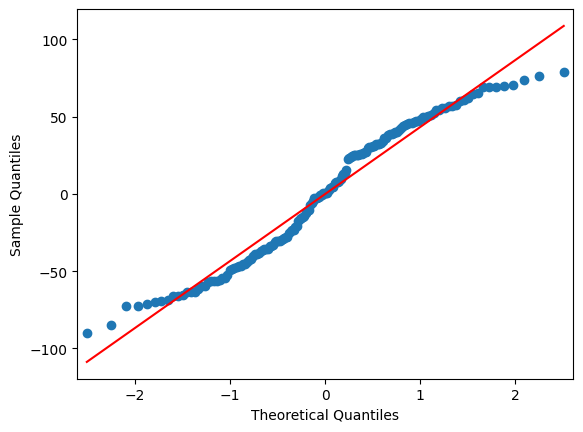

In [47]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [48]:
import pickle
with open('/home/mplitt/shuffle_pkls/sparse_pc_frac_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    print('nans', np.isnan(shuff_coefs).sum())
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    p = np.minimum(p, 1-p)
    print(f"{stat} true coef = {true_coef}, p = {p} ")

nans 50
rzone_bool true coef = 0.08606332879216182, p = 0.0 
nans 66
rank_frac true coef = 59.71428571428539, p = 0.0 


In [49]:
model_shuff_results['rank_frac']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                               chi2                 P>chi2  df constraint
Intercept                     [[6.753686730823667]]   0.009355417778946032              1
C(chan)                       [[8.670489892275096]]  0.0032340424056624116              1
C(day)                         [[4.26996693648243]]     0.5112374492192262              5
C(ttype)                 [[1.2405980134813421e-05]]     0.9971896869232857              1
C(chan):C(day)                [[4.634208289890478]]    0.46213003503526917              5
C(chan):C(ttype)             [[0.2334557341762412]]     0.6289732086512003              1
C(day):C(ttype)              [[3.1957804531760403]]      0.669831442175868              5
C(chan):C(day):C(ttype)      [[3.8269138726136798]]     0.5745956084440771              5

In [50]:
res = pg.pairwise_tests(data = df, within=['ttype', 'chan'], dv='frac', subject='mouse',
                        parametric=False, padjust='holm')

res

,Contrast,ttype,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ttype,-,fam,nov,True,False,14.0,two-sided,1.000000,NaN,NaN,-0.102823
1,chan,-,channel_0,channel_1,True,False,11.0,two-sided,0.687500,NaN,NaN,-0.085425
2,ttype * chan,fam,channel_0,channel_1,True,False,7.0,two-sided,0.296875,0.59375,holm,0.180015
3,ttype * chan,nov,channel_0,channel_1,True,False,9.0,two-sided,0.468750,0.59375,holm,-0.203647


In [51]:
res = pg.pairwise_tests(data = df, within=['day', 'chan'], dv='frac', subject='mouse',
                        parametric=False, padjust='holm')

res

,Contrast,day,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,5.0,two-sided,0.31250,1.00000,holm,0.393662
1,day,-,0,2,True,False,6.0,two-sided,0.43750,1.00000,holm,0.382011
2,day,-,0,3,True,False,8.0,two-sided,0.68750,1.00000,holm,-0.137677
3,day,-,0,4,True,False,10.0,two-sided,1.00000,1.00000,holm,0.201462
4,day,-,0,5,True,False,6.0,two-sided,0.43750,1.00000,holm,-0.691832
5,day,-,1,2,True,False,9.0,two-sided,0.84375,1.00000,holm,0.070984
6,day,-,1,3,True,False,5.0,two-sided,0.31250,1.00000,holm,-0.414268
7,day,-,1,4,True,False,9.0,two-sided,0.84375,1.00000,holm,0.012569
8,day,-,1,5,True,False,1.0,two-sided,0.06250,0.81250,holm,-1.046060
9,day,-,2,3,True,False,0.0,two-sided,0.03125,0.46875,holm,-0.419120


r=-0.18, p=0.025


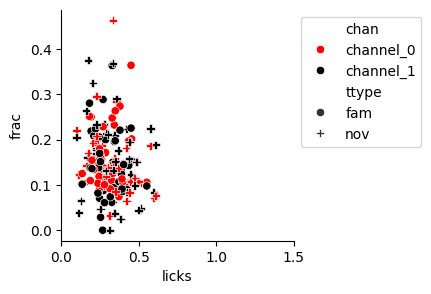

In [52]:
fig, ax = plt.subplots(figsize=[3,3])
sns.scatterplot(data=frac_cls.df,
                x='licks',
                y='frac',
                hue='chan',
                style='ttype',
                markers={'fam':'o', 'nov':'P'},
                alpha=1.,
                palette = {'channel_0':'red', 'channel_1':'black'},
                ax=ax, 
                )
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0,1.5])
fig.savefig(figdir / 'licks_vs_reward_frac.pdf', bbox_inches='tight')


r,p = sp.stats.spearmanr(frac_cls.df['licks'], frac_cls.df['frac'])
print(f'r={r:.2f}, p={p:.3f}')

In [55]:
reward_cells = stx.reward_overrep.RewardCells_Sparse(ts_key='spks')

SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


In [56]:
shuff_df = reward_cells.build_summary_df_for_shuffles()
red_df = shuff_df.groupby(['mouse', 'chan', 'day']).mean().reset_index()
red_df['rank_frac'] = red_df['rzone_bool'].rank()

model = smf.mixedlm(f"rank_frac ~ C(chan) * C(day) ", red_df, groups=red_df["mouse"])
model_result = model.fit()
model_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM        Dependent Variable:        rank_frac
No. Observations:         82             Method:                    REML     
No. Groups:               7              Scale:                     300.0339 
Min. group size:          10             Log-Likelihood:            -317.7996
Max. group size:          12             Converged:                 Yes      
Mean group size:          11.7                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         39.000    9.020  4.324 0.000  21.321 56.679
C(chan)[T.channel_1]             -11.143    9.259 -1.203 0.229 -29.290  7.004
C(day)[T.1]                        1.429    9.259  0.154 0.877 -16.718 19.575
C(day)[T.2]                       10.360    9.671  1.071 0.284  -8.595 29.314
C(day)[T.3]                       10.000    9.259  1.080 0.280  -8.147 28.147
C(day)[T.4]                        5.714    9.259  0.617 0.537 -12.432 23.861
C(day)[T.5]                       20.000    9.259  2.160 0.031   1.853 38.147
C(chan)[T.channel_1]:C(day)[T.1]   7.571   13.094  0.578 0.563 -18.092 33.235
C(chan)[T.channel_1]:C(day)[T.2]  -5.524   13.628 -0.405 0.685 -32.235 21.188
C(chan)[T.channel_1]:C(day)[T.3]   7.143   13.094  0.546 0.585 -18.521 32.806
C(chan)[T.channel_1]:C(day)[T.4]  -1.857   13.094 -0.142 0.887 -27.521 23.806
C(chan)[T.channel_1]:C(day)[T.5]  -2.429   13.094 -0.185 0.853 -28.092 23.235
Group Var                        269.508   10.282                            
=============================================================================

"""

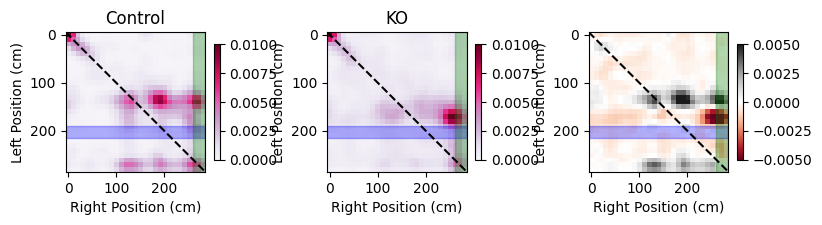

In [57]:
fig, ax = reward_cells.plot_heatmaps(5, vmax=.01, diff_max=.005)
# fig.savefig(figdir / "reward_cells_day5_hist.pdf")

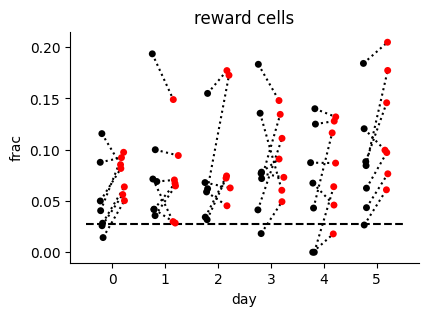

In [58]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=reward_cells.summary_df,
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


# sns.pointplot(data=reward_cells.summary_df,
#             x='day',
#             y='frac',
#             errorbar=None,
#             hue='chan',
#             hue_order = ['channel_0', 'channel_1'],
#             dodge = .4,
#             palette = ['red','black'],
#             ax=ax,
#             linestyles="none",
#             marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
#             )
ax.set_title('reward cells')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.hlines((5/30)**2, -.5,5.5, linestyle='--', color='black')

# fig.savefig( figdir / 'reward_cells_per_day.pdf', bbox_inches='tight')

In [19]:
with open('/home/mplitt/shuffle_pkls/sparse_rewardcell_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    print('nans', np.isnan(shuff_coefs).sum())
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    p = np.minimum(p, 1-p)
    print(f"{stat} true coef = {true_coef}, p = {p} ")

nans 0
rzone_bool true coef = [28.28202038], p = 0.0022 
nans 0
rank_frac true coef = [89.79725745], p = 0.0005 


In [20]:
model_shuff_results['rank_frac']['true_model']

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,day,2848.944444,5,25,569.788889,2.069723,0.103125,0.158656,0.121499,0.518922
1,chan,15225.125000,1,5,15225.125000,89.797257,0.000221,0.000221,0.424991,1.000000
2,day * chan,668.333333,5,25,133.666667,0.653685,0.661490,0.556058,0.031425,0.450539


In [21]:
# model_shuff_results['rank_frac']['true_model'].wald_test_terms()

In [22]:
frac_cls.df.head()

,mouse,chan,day,ttype,lr,frac,licks,speed,peaks_rz_centered
0,SparseKO_02,channel_0,0,fam,1,0.140351,0.253836,13.665863,"[-22.33365218636522, 1.6663478136347791, -17.3..."
1,SparseKO_02,channel_1,0,fam,1,0.000000,0.253836,13.665863,"[-7.333652186365221, -19.33365218636522, -7.33..."
2,SparseKO_02,channel_0,0,nov,-1,0.144068,0.208336,15.139471,"[-1.1769044573882397, 2.8230955426117603, -8.1..."
3,SparseKO_02,channel_1,0,nov,-1,0.194444,0.208336,15.139471,"[-6.17690445738824, -4.17690445738824, -10.176..."
4,SparseKO_02,channel_0,1,fam,1,0.165289,0.237283,16.738874,"[-5.333652186365221, -10.33365218636522, -1.33..."


In [23]:
df = frac_cls.df

bins = np.arange(-30, 20)

peaks_dict = {}
for day in range(6):
    peaks_dict[day] = {}
    for ttype in ('fam', 'nov'):
        peaks_dict[day][ttype]={}
        for chan in ('channel_0', 'channel_1'):
            peaks_dict[day][ttype][chan] = []
            for mouse in sparse_mice:
                if mouse == 'SparseKO_09' and day ==2:
                    continue
                mask = (df['mouse']==mouse) * (df['day']==day) * (df['ttype']==ttype) * (df['chan']==chan)
                peaks_rz_centered = df.loc[mask,'peaks_rz_centered']
                # print(peaks_rz_centered.values[0])
                # print(np.isnan(peaks_rz_centered.values))

                hist,_ = np.histogram(peaks_rz_centered.values[0], bins)
                peaks_dict[day][ttype][chan].append(hist/hist.sum())
            peaks_dict[day][ttype][chan] = np.array(peaks_dict[day][ttype][chan])


/tmp/ipykernel_475682/1336783983.py:21: RuntimeWarning: invalid value encountered in divide
  peaks_dict[day][ttype][chan].append(hist/hist.sum())


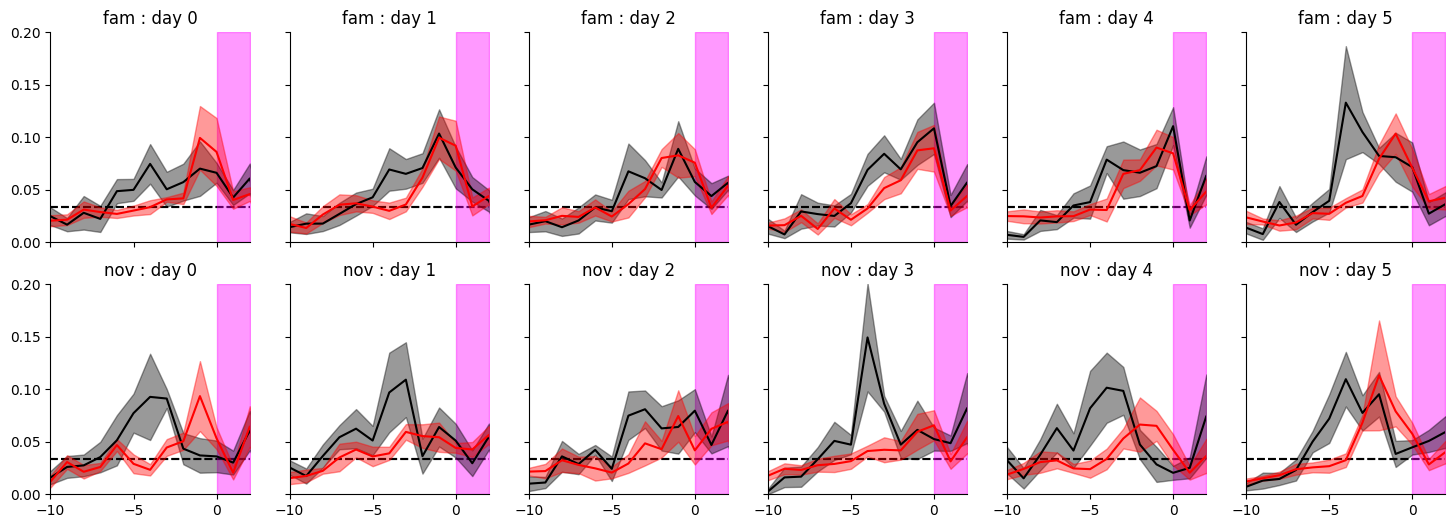

In [24]:
fig, ax = plt.subplots(2,6, figsize=[18,6], sharex=True, sharey=True)
for chan, color in zip(('channel_1', 'channel_0'), ('black', 'red')):
    for day in range(6):
        for row, ttype in enumerate(('fam', 'nov')):
            mu = np.nanmean(peaks_dict[day][ttype][chan], axis=0)
            sem = sp.stats.sem(peaks_dict[day][ttype][chan], axis=0, nan_policy='omit')
            ax[row, day].plot(bins[:-1],mu, color=color )
            ax[row, day].fill_between(bins[:-1], mu-sem, mu+sem, color=color, alpha=.4)
            ax[row, day].set_title(f'{ttype} : day {day}')
            ax[row, day].plot([-10, 2], [1./30, 1./30], 'k--', zorder=-2) #color='black', linestyle='dashed')

for a in ax.flatten():
    a.fill_betweenx([0,.2], 0, 2, color='magenta', alpha=.4, zorder=-1)
    a.set_xlim([-10,2])
    a.set_ylim([0,.2])
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)


fig.savefig(figdir / "sparse_reward_frac_v_pos.pdf")